In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
data=fetch_california_housing(as_frame=True)
df=pd.concat([data.data,data.target.rename('MedHouseVal')],axis=1)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


BASIC EDA

In [ ]:
print("shape of dataset:")
df.shape

shape of dataset:


(20640, 9)

In [ ]:
print("first 5 rows:")
df.head()

first 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
print("Summary Statistics:")
df.describe()

Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
print("Missing values:")
df.isnull().sum()

Missing values:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


The dataset contains no missing values

Histogram of all features

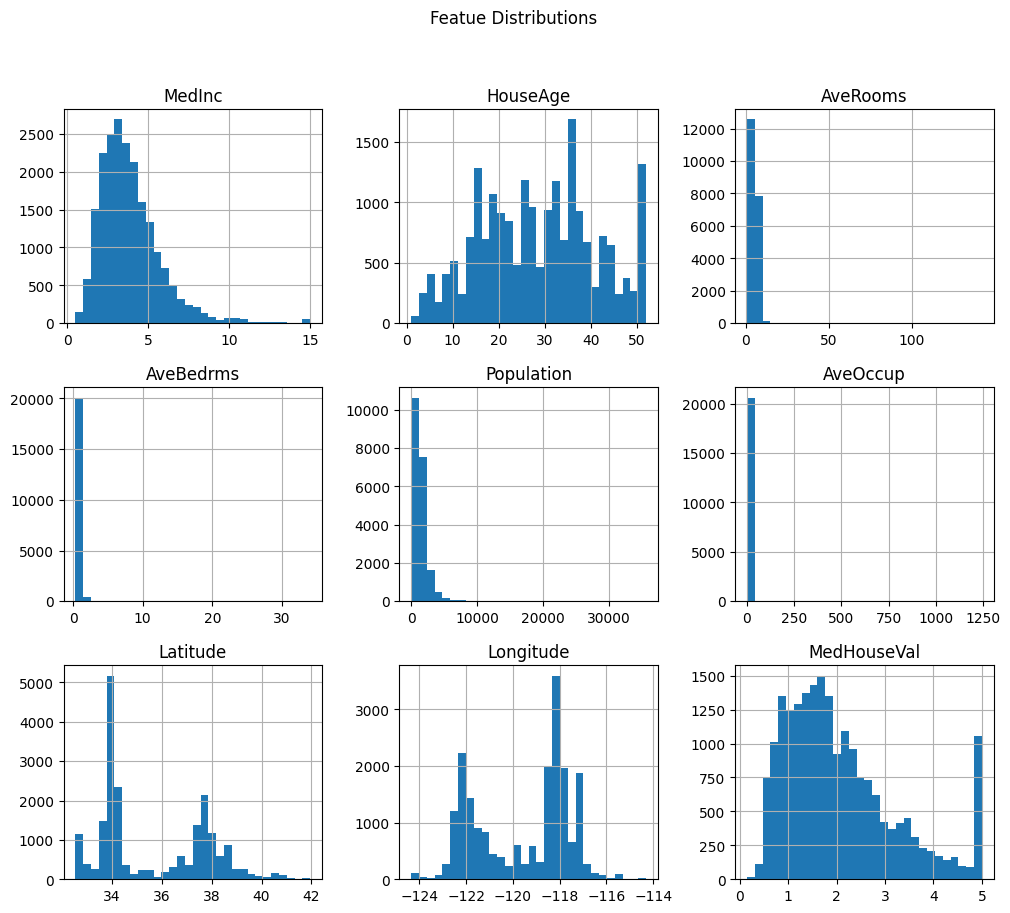

In [ ]:
df.hist(figsize=(12,10),bins=30)
plt.suptitle("Featue Distributions")
plt.show()

Distribution of House values

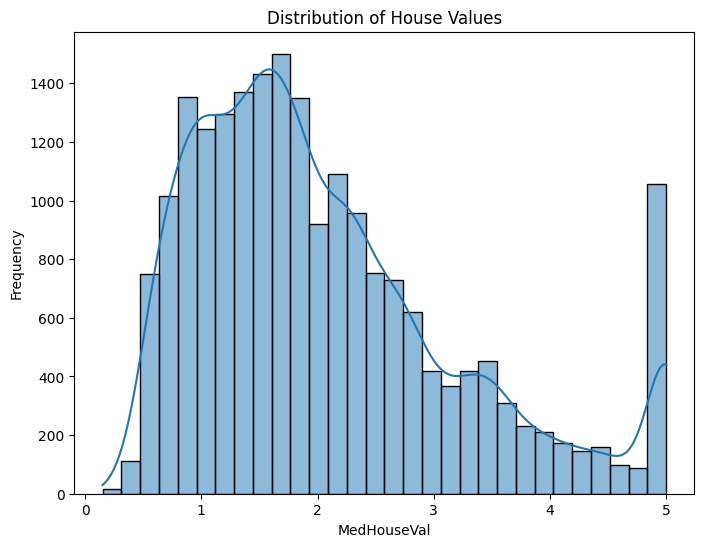

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['MedHouseVal'],bins=30,kde=True)
plt.title("Distribution of House Values")
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.show()

Median Income vs House value

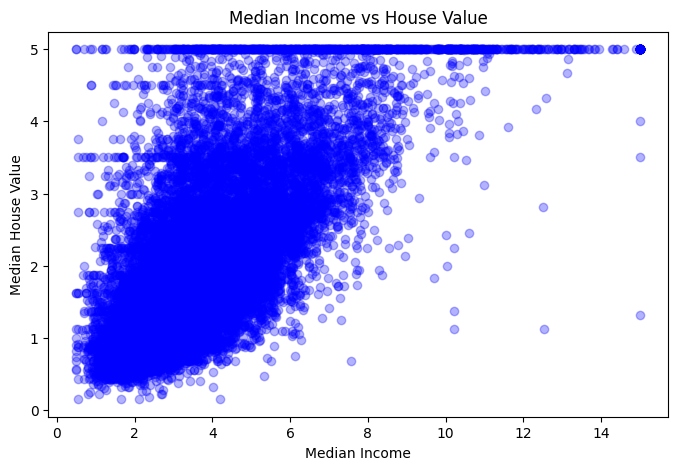

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['MedInc'],
    df['MedHouseVal'],
    alpha=0.3,
    color='blue'
)
plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

House Age vs House Value

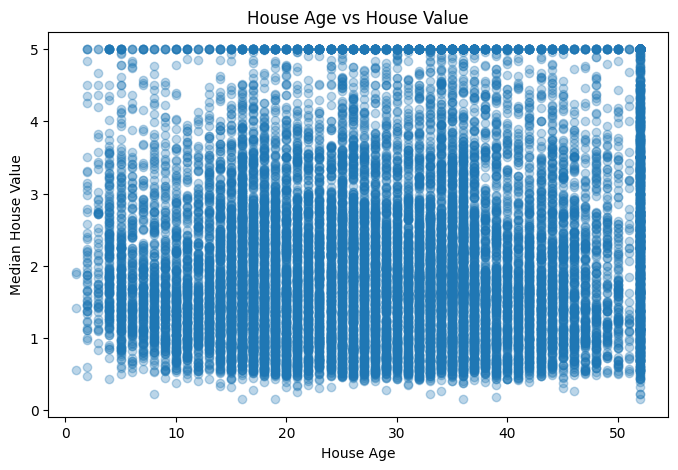

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['HouseAge'],
    df['MedHouseVal'],
    alpha=0.3
)

plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.title("House Age vs House Value")

plt.show()

Boxplots for outlier detection

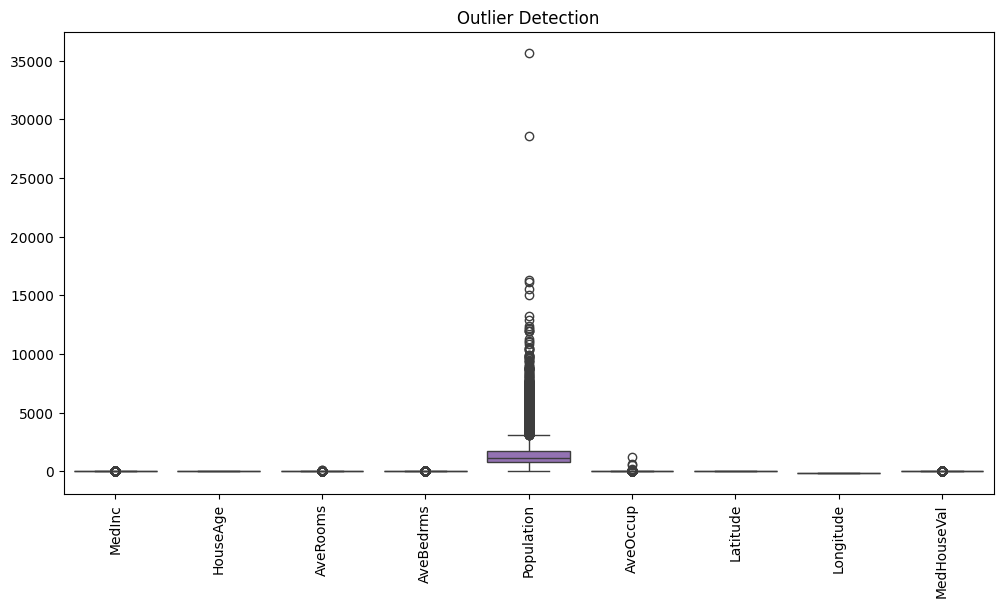

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Outlier Detection')
plt.show()

Correlation Heatmap

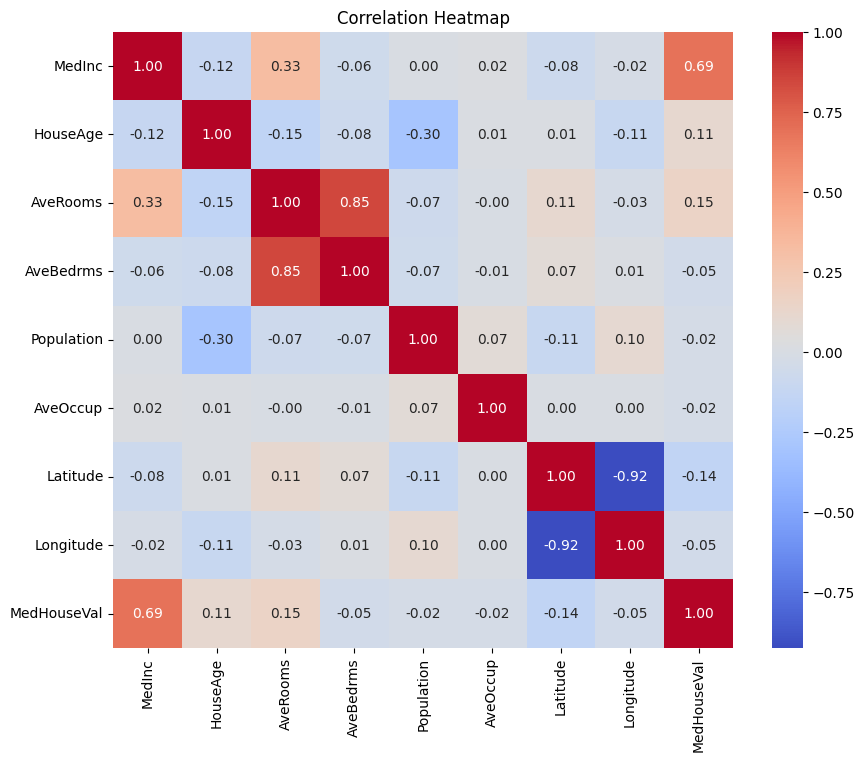

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Feature selection
X=df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']

In [ ]:
#Train-Test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [ ]:
#Model training
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [ ]:
model.intercept_

np.float64(-37.02327770606409)

In [ ]:
#Prediction
y_pred=model.predict(X_test)

NEW PREDICTION

In [ ]:
MedInc = float(input("Median Income: "))
HouseAge = float(input("House Age: "))
AveRooms = float(input("Average Rooms: "))
AveBedrms = float(input("Average Bedrooms: "))
Population = float(input("Population: "))
AveOccup = float(input("Average Occupancy: "))
Latitude = float(input("Latitude: "))
Longitude = float(input("Longitude: "))

new_house = [[MedInc, HouseAge, AveRooms, AveBedrms,
              Population, AveOccup, Latitude, Longitude]]

prediction = model.predict(new_house)

print("Predicted House Value:", prediction[0])

Median Income: 8.3252
House Age: 41
Average Rooms: 6.98
Average Bedrooms: 1.02
Population: 322
Average Occupancy: 2.55
Latitude: 37.88
Longitude: -122.23
Predicted House Value: 4.149487820720765


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#Evaluation Metrics
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)

Mean Absolute Error: 0.5332001304956553
Root Mean Squared Error: 0.7455813830127764
R-squared: 0.5757877060324508


Actual vs Predicted plot

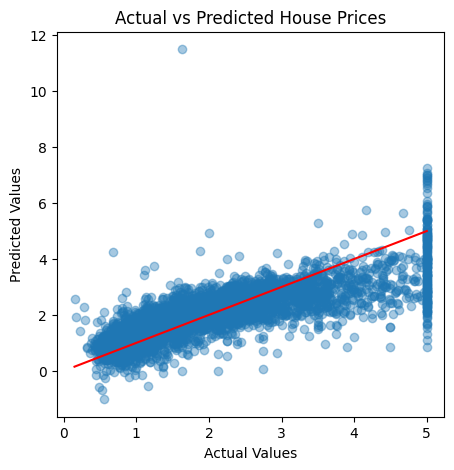

In [ ]:
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color="red"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")

plt.show()

Residual Plot

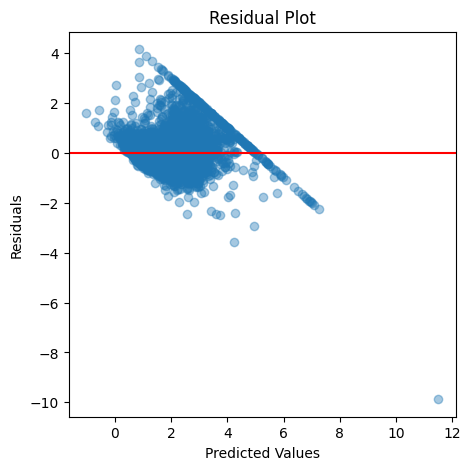

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(5,5))
plt.scatter(y_pred, residuals, alpha=0.4)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

End of Assignment 1